## **CEFR Explorer**

CEFR is a level adaptation mofel that classifies data into 5 different levels - A1 to C1 - based on; Vocabulary difficulty, sentence complexity, explanation difficulty and question difficulty.

In [1]:
!pip install datasets -q

from datasets import load_dataset
from collections import Counter
import numpy as np
import difflib

### **EDA**

In [2]:
cefr = load_dataset("yasincicek/English-CEFR-Explorer")["train"]
print(len(cefr))
print(cefr[0])
print(cefr[5])

README.md:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

final_english_dataset.jsonl:   0%|          | 0.00/4.78M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3053 [00:00<?, ? examples/s]

3053
{'messages': [{'role': 'system', 'content': 'You are an expert English teacher creating reading materials for CEFR level A1.'}, {'role': 'user', 'content': 'Write a passage about My Daily Routine including these words: wake up, eat, go to bed, brush teeth, work, sleep.'}, {'role': 'assistant', 'content': 'Here is a reading passage about "My Daily Routine" for CEFR A1:\n\nHello! My name is Ana. I want to tell you about my day. Every morning, I **wake up** at six o\'clock. The sun is often rising. First, I go to the bathroom and **brush teeth**. It makes my mouth feel fresh. Then, I **eat** a quick breakfast. I usually have fruit and milk. It gives me energy for the day.\n\nAfter breakfast, I get ready for **work**. I am a gardener. I love my job! I help plants grow big and strong. My **work** finishes at three o\'clock. Then, I go home. In the evening, I relax. I like to read a book or listen to music. Around seven o\'clock, I **eat** dinner with my husband. We talk about our day. 

The dataset has 3,053 examples. Each one is not a single sentence but a full 3-message exchange (a system instruction assigning a CEFR level and topic, a user request naming vocabulary to include, and an assistant reply containing the generated reading passage). This tells us the dataset was synthetically generated for controlled passage-writing, not collected from real learner speech or organic conversation.

In [3]:
roles_seen = set()
turn_counts = []

for ex in cefr.select(range(500)):
  msgs = ex["messages"]
  turn_counts.append(len(msgs))
  for m in msgs:
    roles_seen.add(m.get("role"))

print("roles seen:", roles_seen)
print("turn counts - min:", min(turn_counts), "max:", max(turn_counts), "mean:", np.mean(turn_counts))

roles seen: {'assistant', 'user', 'system'}
turn counts - min: 3 max: 3 mean: 3.0


 Every example has exactly 3 messages — min, max, and mean all equal 3. This confirms the dataset is single-turn instruction data (one prompt in, one generated passage out), not multi-turn dialogue. For our goal of holding a live conversation, this dataset won't teach turn-taking on its own — that's DailyDialog's job. What this dataset is good for is teaching the model to produce text calibrated to a specific level, which is exactly the piece we need for level-adaptive replies.

In [4]:
print(cefr[0]["scientific_metadata"])
print(cefr[10]["scientific_metadata"])

meta_keys = set()
for ex in cefr.select(range(500)):
  md = ex["scientific_metadata"]
  if isinstance(md, dict):
    meta_keys.update(md.keys())

print(meta_keys)

{'topic': 'My Daily Routine', 'target_level': 'A1', 'constraints': {'target_vocabulary': ['wake up', 'eat', 'go to bed', 'brush teeth', 'work', 'sleep']}}
{'topic': 'My Favorite Holiday', 'target_level': 'A2', 'constraints': {'target_vocabulary': ['celebrate', 'tradition', 'present', 'family', 'decorate', 'special', 'holiday']}}
{'constraints', 'topic', 'target_level'}


Each example carries structured metadata — topic, target_level, and constraints (required vocabulary). This metadata is the actual training signal for level adaptation: it's the label we want the model to learn to condition its output on.

In [5]:
levels = [ex["scientific_metadata"].get("target_level") for ex in cefr]
print(Counter(levels))

Counter({'C1': 757, 'B1': 601, 'B2': 569, 'C2': 488, 'A2': 372, 'A1': 266})


The level distribution is uneven and doesn't fall on a simple pattern — it rises from A1 (266) up through B1 (601), dips slightly at B2 (569), peaks at C1 (757), then drops back down at C2 (488). C1 is nearly 3x as represented as A1. Left as-is, the model will see roughly 3x more C1 examples than A1 examples, which risks it becoming noticeably better at generating/adapting to upper-intermediate language than true beginner language. Decision to make: rebalance (down-sample C1/B1 or up-sample A1/A2) now, or leave it and specifically evaluate beginner-level output quality separately later rather than trusting one overall score.

In [6]:
print(type(cefr))
print(type(cefr[0]))
print(cefr[0].keys())
print(type(cefr[0]["scientific_metadata"]))
print(cefr[0]["scientific_metadata"])

<class 'datasets.arrow_dataset.Dataset'>
<class 'dict'>
dict_keys(['messages', 'scientific_metadata'])
<class 'dict'>
{'topic': 'My Daily Routine', 'target_level': 'A1', 'constraints': {'target_vocabulary': ['wake up', 'eat', 'go to bed', 'brush teeth', 'work', 'sleep']}}


This is a structural sanity check, not a finding — it confirms cefr is a HuggingFace Dataset of dicts with exactly two top-level fields (messages, scientific_metadata). Useful to know before writing cleaning/formatting code against these exact keys, since a typo here would silently produce empty results rather than an error.

In [7]:
import statistics

by_level = {}

for ex in cefr:

    # Get CEFR level
    level = ex["scientific_metadata"].get("target_level")

    if level is None:
        continue

    # Combine the message contents
    text = " ".join(m["content"] for m in ex["messages"])

    # Count words
    word_count = len(text.split())

    # Add word count to the appropriate CEFR level
    if level not in by_level:
        by_level[level] = []

    by_level[level].append(word_count)


# Print results
for level in sorted(by_level):

    word_counts = by_level[level]

    mean_words = sum(word_counts) / len(word_counts)

    print(f"{level}:")
    print(f"  Number of examples: {len(word_counts)}")
    print(f"  First 5 word counts: {word_counts[:5]}")
    print(f"  Mean words: {mean_words:.1f}")
    print()



A1:
  Number of examples: 266
  First 5 word counts: [198, 207, 138, 154, 162]
  Mean words: 166.9

A2:
  Number of examples: 372
  First 5 word counts: [160, 169, 169, 145, 179]
  Mean words: 173.2

B1:
  Number of examples: 601
  First 5 word counts: [168, 161, 155, 170, 164]
  Mean words: 170.0

B2:
  Number of examples: 569
  First 5 word counts: [170, 168, 169, 165, 196]
  Mean words: 169.1

C1:
  Number of examples: 757
  First 5 word counts: [167, 160, 144, 182, 186]
  Mean words: 169.5

C2:
  Number of examples: 488
  First 5 word counts: [168, 183, 177, 179, 187]
  Mean words: 171.0



Mean word count is nearly flat across every level — roughly 167-173 words regardless of whether the target is A1 or C2. This is a genuinely useful and slightly counterintuitive finding: you might expect beginner (A1) passages to be much shorter than advanced (C2) ones, but they aren't. That's almost certainly because this is a controlled-generation task with an implicit fixed target length — the actual level differentiation lives in vocabulary and sentence complexity, not passage length. **Practical implication: don't use text length as a stand-in signal for CEFR level in this dataset — it carries almost no information here.**

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

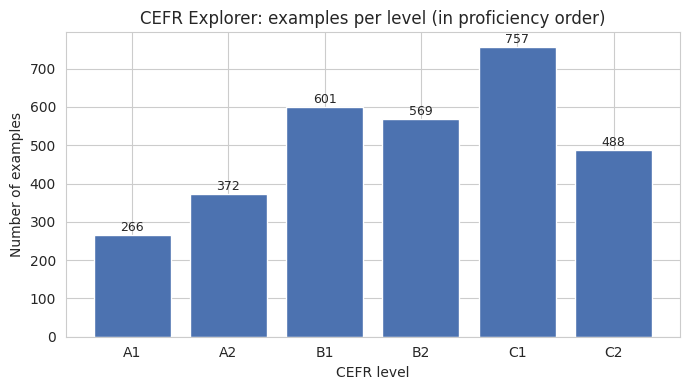

In [9]:
level_order = ["A1", "A2", "B1", "B2", "C1", "C2"]
level_counts = Counter(levels)
counts_ordered = [level_counts.get(lvl, 0) for lvl in level_order]

plt.figure(figsize=(7, 4))
plt.bar(level_order, counts_ordered, color="#4C72B0")
plt.title("CEFR Explorer: examples per level (in proficiency order)")
plt.xlabel("CEFR level")
plt.ylabel("Number of examples")
for x, c in enumerate(counts_ordered):
    plt.text(x, c + 10, str(c), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("cefr_level_distribution.png")
plt.show()

Plotting in proficiency order (A1 -> C2) instead of raw-frequency order makes the imbalance easy to read at a glance: representation isn't a smooth ramp in either direction, it climbs, dips at B2, peaks at C1, then falls at C2. A1 is the clear minority class. If topic suggestions or level-adaptation quality end up weak specifically at A1 during testing, this chart is the reason why.

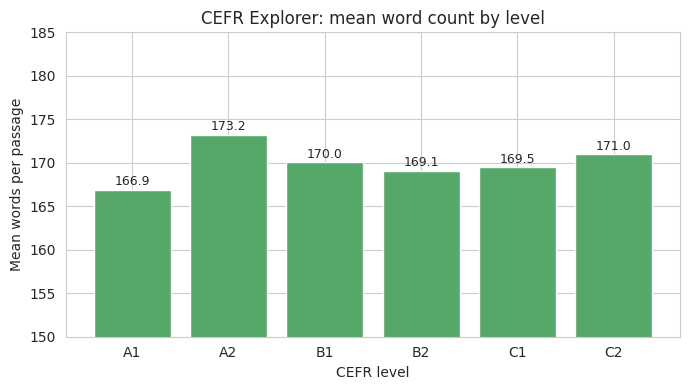

In [10]:
means = [sum(by_level[l]) / len(by_level[l]) for l in level_order if l in by_level]
labels = [l for l in level_order if l in by_level]

plt.figure(figsize=(7, 4))
plt.bar(labels, means, color="#55A868")
plt.ylim(150, 185)  # zoomed in on purpose -- see interpretation below
plt.title("CEFR Explorer: mean word count by level")
plt.xlabel("CEFR level")
plt.ylabel("Mean words per passage")
for x, m in enumerate(means):
    plt.text(x, m + 0.5, f"{m:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("cefr_mean_wordcount_by_level.png")
plt.show()

The y-axis is deliberately zoomed to 150-185 (rather than starting at 0) specifically to make the near-flat line visible -- on a full 0-scale axis this same data would look like six identical bars and hide the (small, real) variation. Even zoomed in, the differences between levels are minor and don't follow a clear increasing or decreasing trend. This visually confirms the finding above: passage length is not a usable proxy for CEFR level in this dataset.

## **JFLEG**
JFLEG is a grammatical error correction and fluency dataset that teaches the model hoe to correct grammatical mistakes, improve sentence fluency and produce more natural English sentences.

### **EDA**

In [11]:
jfleg = load_dataset("jhu-clsp/jfleg")
print(jfleg)

README.md:   0%|          | 0.00/5.94k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  148kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  141kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating validation split:   0%|          | 0/755 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/748 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['sentence', 'corrections'],
        num_rows: 755
    })
    test: Dataset({
        features: ['sentence', 'corrections'],
        num_rows: 748
    })
})


JFLEG only ships validation (755 rows) and test (748 rows) splits -- there is no train split. This is expected: JFLEG was built as an evaluation benchmark for grammar-correction systems, not as a training corpus. Practically, this means we can use JFLEG's validation split as training examples for our merged dataset, but we should hold its test split aside as an untouched, independent check later -- it was never meant to be trained on twice.

In [12]:
ex = jfleg["validation"][0]
print("original:", ex["sentence"])
print("corrections:", ex["corrections"])

original: So I think we can not live if old people could not find siences and tecnologies and they did not developped . 
corrections: ['So I think we would not be alive if our ancestors did not develop sciences and technologies . ', 'So I think we could not live if older people did not develop science and technologies . ', 'So I think we can not live if old people could not find science and technologies and they did not develop . ', 'So I think we can not live if old people can not find the science and technology that has not been developed . ']


Notice the four reference corrections don't just fix typos -- they meaningfully diverge in interpretation ("our ancestors" vs. "older people", "develop" vs. "did not develop"). This tells us JFLEG treats grammar correction as having multiple valid answers, not one ground truth. For our training template, this means picking a single reference per source sentence is a real editorial choice, not just a technicality -- whichever one we pick becomes "the" correct answer the model learns from.

In [13]:
n_refs = [len(e["corrections"]) for e in jfleg["validation"]]
print(Counter(n_refs))

for i in range(3):
  src = jfleg["validation"][i]["sentence"]
  corrs = jfleg["validation"][i]["corrections"]
  print("SRC:", src)
  for c in corrs:
    diff = list(difflib.unified_diff(src.split(), c.split(), lineterm=""))
    print("   ->", c, "| edit ops:", len(diff))

Counter({4: 755})
SRC: So I think we can not live if old people could not find siences and tecnologies and they did not developped . 
   -> So I think we would not be alive if our ancestors did not develop sciences and technologies .  | edit ops: 33
   -> So I think we could not live if older people did not develop science and technologies .  | edit ops: 30
   -> So I think we can not live if old people could not find science and technologies and they did not develop .  | edit ops: 18
   -> So I think we can not live if old people can not find the science and technology that has not been developed .  | edit ops: 26
SRC: For not use car . 
   -> Not for use with a car .  | edit ops: 12
   -> Do not use in the car .  | edit ops: 11
   -> Car not for use .  | edit ops: 10
   -> Can not use the car .  | edit ops: 10
SRC: Here was no promise of morning except that we looked up through the trees we saw how low the forest had swung . 
   -> Here was no promise of morning , except that we look

Every single validation example has exactly 4 reference corrections (Counter({4: 755})) -- the structure is perfectly consistent, nothing to clean here. The edit-op counts shown for the first 3 examples vary widely (from 10 up to 33), both across examples and across the 4 references for the same sentence -- confirming some sentences need heavy rewrites while others need a light touch, and that even the "correct" rewrite isn't unique.

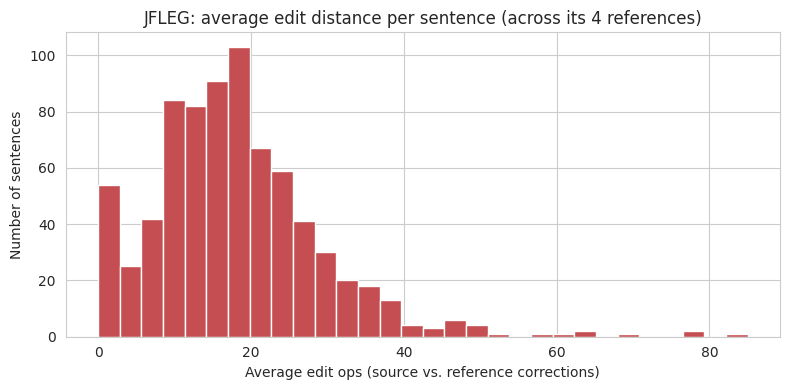

In [14]:
avg_edit_ops = []
for ex in jfleg["validation"]:
    src = ex["sentence"].split()
    ops = []
    for c in ex["corrections"]:
        diff = list(difflib.unified_diff(src, c.split(), lineterm=""))
        ops.append(len(diff))
    avg_edit_ops.append(np.mean(ops))

plt.figure(figsize=(8, 4))
plt.hist(avg_edit_ops, bins=30, color="#C44E52", edgecolor="white")
plt.title("JFLEG: average edit distance per sentence (across its 4 references)")
plt.xlabel("Average edit ops (source vs. reference corrections)")
plt.ylabel("Number of sentences")
plt.tight_layout()
plt.savefig("jfleg_avg_edit_distance.png")
plt.show()

This extends the 3-example spot-check above to the full 755-sentence validation set. Most sentences cluster at a moderate edit distance, with a long right tail of sentences needing heavy rewriting. This matters for training: a dataset with mostly light edits teaches the model "nudge this sentence," while the long tail teaches "substantially rewrite this." Both behaviors are present here, which is good -- but if we ever filter or downsample this dataset, we should check we're not accidentally stripping out the heavy-edit tail and losing that skill.

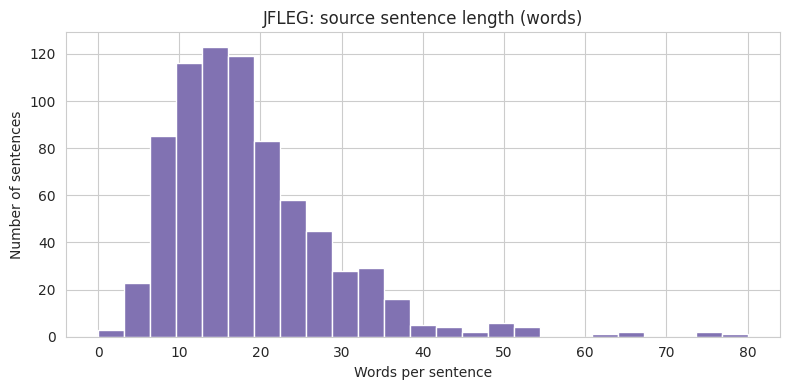

In [15]:
sentence_lengths = [len(ex["sentence"].split()) for ex in jfleg["validation"]]

plt.figure(figsize=(8, 4))
plt.hist(sentence_lengths, bins=25, color="#8172B2", edgecolor="white")
plt.title("JFLEG: source sentence length (words)")
plt.xlabel("Words per sentence")
plt.ylabel("Number of sentences")
plt.tight_layout()
plt.savefig("jfleg_sentence_length.png")
plt.show()

JFLEG sentences are short -- almost all single sentences rather than paragraphs, in contrast to CEFR Explorer's ~170-word passages. This is an important cross-dataset difference to carry into the merged training template: our shared format needs to comfortably handle both a one-line grammar-correction example and a multi-paragraph level-adapted passage side by side.

## **Cleaning**

### **CEFR Explorer**

In [16]:
def is_valid_cefr_example(ex):
  level = ex["scientific_metadata"].get("target_level")
  if level not in {"A1", "A2", "B1", "B2", "C1"}:
    return False
  if not ex["messages"] or any(not m.get("content", "").strip() for m in ex["messages"]):
    return False
  return True

cefr_clean = cefr.filter(is_valid_cefr_example)
print(f"{len(cefr)} -> {len(cefr_clean)} after cleaning")

Filter:   0%|          | 0/3053 [00:00<?, ? examples/s]

3053 -> 2565 after cleaning


3,053 -> 2,565 after cleaning, a drop of exactly 488 examples. That number is not a coincidence -- it's exactly the size of the C2 group from the level-distribution chart above. Look at the filter: if level not in {"A1", "A2", "B1", "B2", "C1"} -- C2 is missing from that set. Every C2 example is being dropped by this filter, not because anything is wrong with those examples, but because the valid-level list is incomplete. This is very likely an unintentional bug: standard CEFR has six levels (A1-C2), and as-written this cleaning step silently deletes an entire level's worth of training data. Worth fixing (add "C2" to the set) unless there's a deliberate reason to exclude C2 -- and if there is, it's worth noting explicitly rather than leaving it implicit in a set literal.

### **JFLEG**

In [17]:
def is_valid_jfleg_example(ex):
  if not ex["sentence"].strip():
    return False
  if not ex["corrections"] or all(not c.strip() for c in ex["corrections"]):
    return False
  return True

jfleg_clean = jfleg["validation"].filter(is_valid_jfleg_example)
print(f"{len(jfleg['validation'])} -> {len(jfleg_clean)} after cleaning")

Filter:   0%|          | 0/755 [00:00<?, ? examples/s]

755 -> 754 after cleaning


755 -> 754 after cleaning -- only one example dropped. Unlike the CEFR filter above, this one behaves as expected: the JFLEG validation split was already close to clean, so there's very little to remove.

In [18]:
print(cefr.features)
print(cefr[:2]) # Display the first two examples

{'messages': List({'role': Value('string'), 'content': Value('string')}), 'scientific_metadata': {'topic': Value('string'), 'target_level': Value('string'), 'constraints': {'target_vocabulary': List(Value('string'))}}}
{'messages': [[{'role': 'system', 'content': 'You are an expert English teacher creating reading materials for CEFR level A1.'}, {'role': 'user', 'content': 'Write a passage about My Daily Routine including these words: wake up, eat, go to bed, brush teeth, work, sleep.'}, {'role': 'assistant', 'content': 'Here is a reading passage about "My Daily Routine" for CEFR A1:\n\nHello! My name is Ana. I want to tell you about my day. Every morning, I **wake up** at six o\'clock. The sun is often rising. First, I go to the bathroom and **brush teeth**. It makes my mouth feel fresh. Then, I **eat** a quick breakfast. I usually have fruit and milk. It gives me energy for the day.\n\nAfter breakfast, I get ready for **work**. I am a gardener. I love my job! I help plants grow big a

In [19]:
print(jfleg['validation'].features)
print(jfleg['validation'][:2]) # Display the first two examples from the 'validation' split

{'sentence': Value('string'), 'corrections': List(Value('string'))}
{'sentence': ['So I think we can not live if old people could not find siences and tecnologies and they did not developped . ', 'For not use car . '], 'corrections': [['So I think we would not be alive if our ancestors did not develop sciences and technologies . ', 'So I think we could not live if older people did not develop science and technologies . ', 'So I think we can not live if old people could not find science and technologies and they did not develop . ', 'So I think we can not live if old people can not find the science and technology that has not been developed . '], ['Not for use with a car . ', 'Do not use in the car . ', 'Car not for use . ', 'Can not use the car . ']]}


## **Converting CEFR & JFLEG to Qwen3 Chat format**

In [20]:
System_Prompt = (
    "You are an English conversation tutor. "
    "Adapt your language to the learner's CEFR level, "
    "keep the conversation natural and engaging, "
    "and help the learner improve their English."
)

### **CEFR**

In [26]:
def convert_cefr(dataset):

  converted = []
  for example in dataset:
    metadata = example["scientific_metadata"]
    topic = metadata["topic"]
    level = metadata["target_level"]
    vocabulary = metadata["constraints"]["target_vocabulary"]
    original_messages = example["messages"]
    assistant_response = original_messages[-1]["content"]

    user_content = (
        f"LEARNER_LEVEL: {level}\n"
        f"TOPIC: {topic}\n"
        f"USER: {original_messages[1]['content']}\n"
        f"TARGET_VOCABULARY: {', '.join(vocabulary)}\n\n"
        "Task: Create reading material appropriate fro the learner's level.\n"
    )
    converted.append({
          "messages": [
              {"role": "system", "content": System_Prompt},
              {"role": "user",
               "content": user_content},

              {"role": "assistant", "content": assistant_response}
          ]})
  return converted

### **JFLEG**

In [24]:
def convert_jfleg(dataset):

  converted = []
  for example in dataset:
    original_sentence = example["sentence"]
    corrections = example["corrections"]
    for correction in corrections:
      converted.append({
          "messages": [
              {"role": "system", "content": System_Prompt},
              {"role": "user",
               "content": ("LEARNER_LEVEL : Unknown\n"
              "Task: Correct the learner's English.\n\n"
              f"USER: {original_sentence}")
               },
              {"role": "assistant", "content": correction}
          ]})
  return converted

In [27]:
cefr_chat = convert_cefr(cefr_clean)
print("Number of CEFR chat examples:", len(cefr_chat))
print("\nFirst CEFR example:")
print(cefr_chat[0])

Number of CEFR chat examples: 2565

First CEFR example:
{'messages': [{'role': 'system', 'content': "You are an English conversation tutor. Adapt your language to the learner's CEFR level, keep the conversation natural and engaging, and help the learner improve their English."}, {'role': 'user', 'content': "LEARNER_LEVEL: A1\nTOPIC: My Daily Routine\nUSER: Write a passage about My Daily Routine including these words: wake up, eat, go to bed, brush teeth, work, sleep.\nTARGET_VOCABULARY: wake up, eat, go to bed, brush teeth, work, sleep\n\nTask: Create reading material appropriate fro the learner's level.\n"}, {'role': 'assistant', 'content': 'Here is a reading passage about "My Daily Routine" for CEFR A1:\n\nHello! My name is Ana. I want to tell you about my day. Every morning, I **wake up** at six o\'clock. The sun is often rising. First, I go to the bathroom and **brush teeth**. It makes my mouth feel fresh. Then, I **eat** a quick breakfast. I usually have fruit and milk. It gives m

In [28]:
fleg_chat = convert_jfleg(jfleg["validation"])
print("Number of JFLEG chat examples:", len(fleg_chat))
print("\nFirst JFLEG example:")
print(fleg_chat[0])

Number of JFLEG chat examples: 3020

First JFLEG example:
{'messages': [{'role': 'system', 'content': "You are an English conversation tutor. Adapt your language to the learner's CEFR level, keep the conversation natural and engaging, and help the learner improve their English."}, {'role': 'user', 'content': "LEARNER_LEVEL : Unknown\nTask: Correct the learner's English.\n\nUSER: So I think we can not live if old people could not find siences and tecnologies and they did not developped . "}, {'role': 'assistant', 'content': 'So I think we would not be alive if our ancestors did not develop sciences and technologies . '}]}
